In [1]:
import pandas as pd
import numpy as np
import shap
import warnings
import joblib
import sys
import psutil
import GPUtil
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV, cross_validate, GroupKFold, cross_val_predict, ParameterGrid
from collections import defaultdict
from time import time
from datetime import timedelta
from importlib.metadata import version

# printout of python version
print("="*50, "Python Version", "="*50)
print(f"python version: {sys.version}")
print(f"xgboost:        {version('xgboost')}")
print(f"shap:           {version('shap')}")

# printout of hardware
print("="*50, "Hardware", "="*50)
gpus = GPUtil.getGPUs()
for gpu in gpus:
    print(f"GPU: {gpu.name}")
print(f"CPU cores: {psutil.cpu_count(logical=False)}")
print(f"RAM: {psutil.virtual_memory().total / 1024 / 1024 / 1024 :.2f} GB")

warnings.filterwarnings('ignore')

================================================== Python Version ==================================================
python version: 3.12.7 | packaged by Anaconda, Inc. | (main, Oct  4 2024, 13:17:27) [MSC v.1929 64 bit (AMD64)]
xgboost:        2.1.1
shap:           0.46.0
================================================== Hardware ==================================================
GPU: NVIDIA GeForce RTX 4090
CPU cores: 16
RAM: 63.82 GB


# read data function

In [2]:
def read_abcd(path, cols, na_values):
    
    df = pd.read_csv(path, sep='\t', index_col='subjectkey', na_values=na_values)
    df = df.drop(df.index[0])
    
    for col in cols:
        df[col] = pd.to_numeric(df[col])
        df = df[cols]

    df = df.reset_index()
    df = df.sort_values(['subjectkey', 'interview_age'])
    df = df.drop_duplicates(subset=['subjectkey'], keep='first')
    df = df.drop(columns=['interview_age'])
    df = df.set_index('subjectkey')
    
    df_show = abcd_ysu02.join(df)
    df_show = df_show.drop(columns=[
        'isip_1d_2',
        'isip_5_2',
        'isip_1b_yn'
    ])
     
    for col in df_show.columns:
        print('{:<30}    n = {:<10}    mean = {:<10.4f}    sum = {:<10.1f}'.\
              format(col,  df_show[col].notnull().sum(), df_show[col].mean(), df_show[col].sum()))    
    print('\nsubjects:{:>10}\nfeatures:{:>10}'.format(df_show.shape[0], df_show.shape[1]))
    
    return df

# y-target variable

In [3]:
file_abcd_ysu02 = r'D:\gregn\data\ABCD\abcd3\abcd_ysu02.txt'
abcd_ysu02 = pd.read_csv(file_abcd_ysu02, sep='\t', index_col='subjectkey')
abcd_ysu02 = abcd_ysu02.drop(abcd_ysu02.index[0])
cols = [
    'interview_age',
    'isip_1d_2',
    'isip_5_2',
    'isip_1b_yn'
]

for col in cols:
    abcd_ysu02[col] = pd.to_numeric(abcd_ysu02[col])
    abcd_ysu02 = abcd_ysu02[cols]
    
abcd_ysu02 = abcd_ysu02.reset_index()
abcd_ysu02 = abcd_ysu02.sort_values(['subjectkey', 'interview_age'])
abcd_ysu02 = abcd_ysu02.drop_duplicates(subset=['subjectkey'], keep='first')
abcd_ysu02 = abcd_ysu02.drop(columns=['interview_age'])
abcd_ysu02 = abcd_ysu02.set_index('subjectkey')
    
abcd_ysu02 = abcd_ysu02.drop(abcd_ysu02[abcd_ysu02.isip_5_2 == 3].index) # drop accidental 
abcd_ysu02 = abcd_ysu02.drop(abcd_ysu02[abcd_ysu02.isip_5_2 == 2].index) # drop furtive 
abcd_ysu02 = abcd_ysu02.drop(abcd_ysu02[abcd_ysu02.isip_1b_yn == 0].index) # drop religious 
abcd_ysu02 = abcd_ysu02.drop(abcd_ysu02[abcd_ysu02.isip_1d_2 > 10].index) # drop older than 10

abcd_ysu02['isip_1d_2'] = abcd_ysu02['isip_1d_2'].fillna(0)

y = abcd_ysu02['isip_1d_2'].values
y = np.where(y>0, 1, y)

unique, counts = np.unique(y, return_counts=True)

print('number of subjects: {:>10}\n\n[0] never sipped: {:>12}\n[1] sipped by age 10:{:>9}'.\
      format(len(y), counts[0], counts[1]))

number of subjects:      10707

[0] never sipped:         9209
[1] sipped by age 10:     1498


# acspsw03

In [4]:
path = r'D:\gregn\data\ABCD\abcd3\acspsw03.txt'

cols = [
    'interview_age',
    'rel_family_id',
]

na_values = [None]
acspsw03 = read_abcd(path, cols, na_values)

rel_family_id                     n = 10707         mean = 5921.1416     sum = 63397663.0

subjects:     10707
features:         1


# abcd_smrip101

In [5]:
path = r'D:\gregn\data\ABCD\abcd3\abcd_smrip101.txt'

cols = [
'interview_age',
'smri_thick_cdk_banksstslh',
'smri_thick_cdk_cdacatelh',
'smri_thick_cdk_cdmdfrlh',
'smri_thick_cdk_cuneuslh',
'smri_thick_cdk_ehinallh',
'smri_thick_cdk_fusiformlh',
'smri_thick_cdk_ifpllh',
'smri_thick_cdk_iftmlh',
'smri_thick_cdk_ihcatelh',
'smri_thick_cdk_locclh',
'smri_thick_cdk_lobfrlh',
'smri_thick_cdk_linguallh',
'smri_thick_cdk_mobfrlh',
'smri_thick_cdk_mdtmlh',
'smri_thick_cdk_parahpallh',
'smri_thick_cdk_paracnlh',
'smri_thick_cdk_parsopclh',
'smri_thick_cdk_parsobislh',
'smri_thick_cdk_parstgrislh',
'smri_thick_cdk_pericclh',
'smri_thick_cdk_postcnlh',
'smri_thick_cdk_ptcatelh',
'smri_thick_cdk_precnlh',
'smri_thick_cdk_pclh',
'smri_thick_cdk_rracatelh',
'smri_thick_cdk_rrmdfrlh',
'smri_thick_cdk_sufrlh',
'smri_thick_cdk_supllh',
'smri_thick_cdk_sutmlh',
'smri_thick_cdk_smlh',
'smri_thick_cdk_frpolelh',
'smri_thick_cdk_tmpolelh',
'smri_thick_cdk_trvtmlh',
'smri_thick_cdk_insulalh',
'smri_thick_cdk_banksstsrh',
'smri_thick_cdk_cdacaterh',
'smri_thick_cdk_cdmdfrrh',
'smri_thick_cdk_cuneusrh',
'smri_thick_cdk_ehinalrh',
'smri_thick_cdk_fusiformrh',
'smri_thick_cdk_ifplrh',
'smri_thick_cdk_iftmrh',
'smri_thick_cdk_ihcaterh',
'smri_thick_cdk_loccrh',
'smri_thick_cdk_lobfrrh',
'smri_thick_cdk_lingualrh',
'smri_thick_cdk_mobfrrh',
'smri_thick_cdk_mdtmrh',
'smri_thick_cdk_parahpalrh',
'smri_thick_cdk_paracnrh',
'smri_thick_cdk_parsopcrh',
'smri_thick_cdk_parsobisrh',
'smri_thick_cdk_parstgrisrh',
'smri_thick_cdk_periccrh',
'smri_thick_cdk_postcnrh',
'smri_thick_cdk_ptcaterh',
'smri_thick_cdk_precnrh',
'smri_thick_cdk_pcrh',
'smri_thick_cdk_rracaterh',
'smri_thick_cdk_rrmdfrrh',
'smri_thick_cdk_sufrrh',
'smri_thick_cdk_suplrh',
'smri_thick_cdk_sutmrh',
'smri_thick_cdk_smrh',
'smri_thick_cdk_frpolerh',
'smri_thick_cdk_tmpolerh',
'smri_thick_cdk_trvtmrh',
'smri_thick_cdk_insularh',
'smri_thick_cdk_meanlh',
'smri_thick_cdk_meanrh',
'smri_thick_cdk_mean',
'smri_vol_cdk_banksstslh',
'smri_vol_cdk_cdacatelh',
'smri_vol_cdk_cdmdfrlh',
'smri_vol_cdk_cuneuslh',
'smri_vol_cdk_ehinallh',
'smri_vol_cdk_fusiformlh',
'smri_vol_cdk_ifpllh',
'smri_vol_cdk_iftmlh',
'smri_vol_cdk_ihcatelh',
'smri_vol_cdk_locclh',
'smri_vol_cdk_lobfrlh',
'smri_vol_cdk_linguallh',
'smri_vol_cdk_mobfrlh',
'smri_vol_cdk_mdtmlh',
'smri_vol_cdk_parahpallh',
'smri_vol_cdk_paracnlh',
'smri_vol_cdk_parsopclh',
'smri_vol_cdk_parsobislh',
'smri_vol_cdk_parstgrislh',
'smri_vol_cdk_pericclh',
'smri_vol_cdk_postcnlh',
'smri_vol_cdk_ptcatelh',
'smri_vol_cdk_precnlh',
'smri_vol_cdk_pclh',
'smri_vol_cdk_rracatelh',
'smri_vol_cdk_rrmdfrlh',
'smri_vol_cdk_sufrlh',
'smri_vol_cdk_supllh',
'smri_vol_cdk_sutmlh',
'smri_vol_cdk_smlh',
'smri_vol_cdk_frpolelh',
'smri_vol_cdk_tmpolelh',
'smri_vol_cdk_trvtmlh',
'smri_vol_cdk_insulalh',
'smri_vol_cdk_banksstsrh',
'smri_vol_cdk_cdacaterh',
'smri_vol_cdk_cdmdfrrh',
'smri_vol_cdk_cuneusrh',
'smri_vol_cdk_ehinalrh',
'smri_vol_cdk_fusiformrh',
'smri_vol_cdk_ifplrh',
'smri_vol_cdk_iftmrh',
'smri_vol_cdk_ihcaterh',
'smri_vol_cdk_loccrh',
'smri_vol_cdk_lobfrrh',
'smri_vol_cdk_lingualrh',
'smri_vol_cdk_mobfrrh',
'smri_vol_cdk_mdtmrh',
'smri_vol_cdk_parahpalrh',
'smri_vol_cdk_paracnrh',
'smri_vol_cdk_parsopcrh',
'smri_vol_cdk_parsobisrh',
'smri_vol_cdk_parstgrisrh',
'smri_vol_cdk_periccrh',
'smri_vol_cdk_postcnrh',
'smri_vol_cdk_ptcaterh',
'smri_vol_cdk_precnrh',
'smri_vol_cdk_pcrh',
'smri_vol_cdk_rracaterh',
'smri_vol_cdk_rrmdfrrh',
'smri_vol_cdk_sufrrh',
'smri_vol_cdk_suplrh',
'smri_vol_cdk_sutmrh',
'smri_vol_cdk_smrh',
'smri_vol_cdk_frpolerh',
'smri_vol_cdk_tmpolerh',
'smri_vol_cdk_trvtmrh',
'smri_vol_cdk_insularh',
'smri_vol_cdk_totallh',
'smri_vol_cdk_totalrh',
'smri_vol_cdk_total',
]

na_values = [None]
abcd_smrip101 = read_abcd(path, cols, na_values)

smri_thick_cdk_banksstslh         n = 10624         mean = 2.7982        sum = 29728.3   
smri_thick_cdk_cdacatelh          n = 10623         mean = 2.8739        sum = 30529.4   
smri_thick_cdk_cdmdfrlh           n = 10624         mean = 2.8674        sum = 30463.4   
smri_thick_cdk_cuneuslh           n = 10623         mean = 2.0543        sum = 21822.3   
smri_thick_cdk_ehinallh           n = 10624         mean = 3.4399        sum = 36545.0   
smri_thick_cdk_fusiformlh         n = 10624         mean = 2.9544        sum = 31387.3   
smri_thick_cdk_ifpllh             n = 10624         mean = 2.7710        sum = 29439.3   
smri_thick_cdk_iftmlh             n = 10624         mean = 3.0703        sum = 32619.0   
smri_thick_cdk_ihcatelh           n = 10623         mean = 2.6955        sum = 28634.5   
smri_thick_cdk_locclh             n = 10624         mean = 2.3240        sum = 24689.9   
smri_thick_cdk_lobfrlh            n = 10624         mean = 2.9806        sum = 31665.9   
smri_thick

# X features

In [6]:
dfs = [
    abcd_ysu02,
    acspsw03,
    abcd_smrip101
]
abcd = dfs[0].join(dfs[1:])

X = abcd.drop(columns=[
    'isip_1d_2',
    'isip_5_2',
    'isip_1b_yn',
    'rel_family_id'
])
X_values = X.values

print('number of features:', X.shape[1])

number of features: 142


# family groups

In [7]:
d = defaultdict(lambda: len(d))
family_groups = [d[x] for x in abcd['rel_family_id']]
family_groups = np.array(family_groups)
print(f"there are {len(np.unique(family_groups))} unique family groups")

there are 9011 unique family groups


# XGBoost: 5x5 nested cross validation

In [8]:
start_time = time()

model = XGBClassifier(
    tree_method = 'gpu_hist',
    objective = 'binary:logistic',
    eval_metric = 'auc',
    random_state = 42, 
)

# hyperparameter grid
params = {
    'learning_rate': [0.005, 0.01, 0.1],
    'max_depth': [4, 6, 8],
    'n_estimators': [100, 500, 1000, 1500, 2000, 2500],
    'colsample_bytree': [0.4, 0.8]
}

# inner loop 
inner_cv = GroupKFold(n_splits=5)
inner_cv = inner_cv.get_n_splits(X_values, y, groups=family_groups)

# outer loop
outer_cv = GroupKFold(n_splits=5)
outer_cv = outer_cv.get_n_splits(X_values, y, groups=family_groups)
  
# inner loop grid search
gs = GridSearchCV(
    estimator=model, 
    param_grid=params, 
    scoring='roc_auc', 
    cv=inner_cv,
    return_train_score=True,
    verbose=3
)
gs.fit(X_values, y)

# multiple metrics 
scoring = ['roc_auc', 'accuracy', 'precision', 'recall', 'f1']

# outer loop scores 
nested_scores = cross_validate(
    gs,
    X=X_values, 
    y=y, 
    scoring=scoring, 
    cv=outer_cv,
)

# obtain model scores from outer folds
y_scores = cross_val_predict(
    gs, 
    X_values, 
    y, 
    cv=outer_cv, 
    method='predict_proba',           
)[:, 1]
df_scores = pd.DataFrame({'y_true': y, 'y_scores': y_scores})
df_scores.to_csv(f'smri_y_true_y_scores.csv', index=False)

auc = nested_scores['test_roc_auc']
acc = nested_scores['test_accuracy']
precision = nested_scores['test_precision']
recall = nested_scores['test_recall']
f1 = nested_scores['test_f1']
print('='*120)
print('\nRuntime:', str(timedelta(seconds=time()-start_time)))
print()
print(f'Average ROC AUC score:      {auc.mean():.4f} {auc}')
print(f'Average accuracy score:     {acc.mean():.4f} {acc}')
print(f'Average precision score:    {precision.mean():.4f} {precision}')
print(f'Average recall score:       {recall.mean():.4f} {recall}')
print(f'Average F1 score:           {f1.mean():.4f} {f1}')
print('\nBest parameters:\n', gs.best_params_)

Fitting 5 folds for each of 108 candidates, totalling 540 fits
[CV 1/5] END colsample_bytree=0.4, learning_rate=0.005, max_depth=4, n_estimators=100;, score=(train=0.745, test=0.560) total time=   0.2s
[CV 2/5] END colsample_bytree=0.4, learning_rate=0.005, max_depth=4, n_estimators=100;, score=(train=0.760, test=0.568) total time=   0.1s
[CV 3/5] END colsample_bytree=0.4, learning_rate=0.005, max_depth=4, n_estimators=100;, score=(train=0.760, test=0.585) total time=   0.1s
[CV 4/5] END colsample_bytree=0.4, learning_rate=0.005, max_depth=4, n_estimators=100;, score=(train=0.752, test=0.597) total time=   0.1s
[CV 5/5] END colsample_bytree=0.4, learning_rate=0.005, max_depth=4, n_estimators=100;, score=(train=0.744, test=0.577) total time=   0.1s
[CV 1/5] END colsample_bytree=0.4, learning_rate=0.005, max_depth=4, n_estimators=500;, score=(train=0.832, test=0.557) total time=   0.5s
[CV 2/5] END colsample_bytree=0.4, learning_rate=0.005, max_depth=4, n_estimators=500;, score=(train=0.

In [9]:
joblib.dump(gs, 'smri_gridsearch.pkl')
joblib.dump(nested_scores, 'smri_nested_scores.pkl')

['smri_nested_scores.pkl']

# SHAP (SHapley Additive exPlanations)

In [10]:
explainer = shap.Explainer(gs.best_estimator_)
shap_values = explainer(X)

# SHAP ranking of top model features

In [11]:
# Create SHAP ranking dataframe
sv_mean = np.abs(shap_values.values).mean(0)
sv_rank = pd.DataFrame(list(zip(X, sv_mean)), columns=['feature', 'mean absolute SHAP value'])
sv_rank = sv_rank.sort_values(by='mean absolute SHAP value', ascending=False)
sv_rank['percent importance'] = sv_rank['mean absolute SHAP value'] / sv_rank['mean absolute SHAP value'].sum()*100
sv_rank['cumulative importance (%)'] = sv_rank['percent importance'].cumsum()
sv_rank.reset_index(inplace=True, drop=True)
sv_rank.to_csv(f'smri_shap_ranking.csv', index=False)

pd.options.display.max_rows = None
print(f"Sum of SHAP values: {sv_rank['mean absolute SHAP value'].sum()}")
sv_rank[:20]

Sum of SHAP values: 1.269753098487854


,feature,mean absolute SHAP value,percent importance,cumulative importance (%)
0,smri_vol_cdk_pcrh,0.058817,4.632184,4.632184
1,smri_thick_cdk_parahpalrh,0.053349,4.201538,8.833721
2,smri_vol_cdk_iftmrh,0.037931,2.987235,11.820955
3,smri_thick_cdk_ifpllh,0.032576,2.565537,14.386493
4,smri_vol_cdk_loccrh,0.026455,2.083459,16.469952
5,smri_vol_cdk_sufrrh,0.024484,1.928266,18.398218
6,smri_vol_cdk_parahpalrh,0.024250,1.909833,20.308052
7,smri_thick_cdk_parsopcrh,0.024206,1.906321,22.214373
8,smri_vol_cdk_total,0.022039,1.735666,23.950039
9,smri_vol_cdk_fusiformlh,0.021875,1.722786,25.672825


# SHAP summary plot of top features

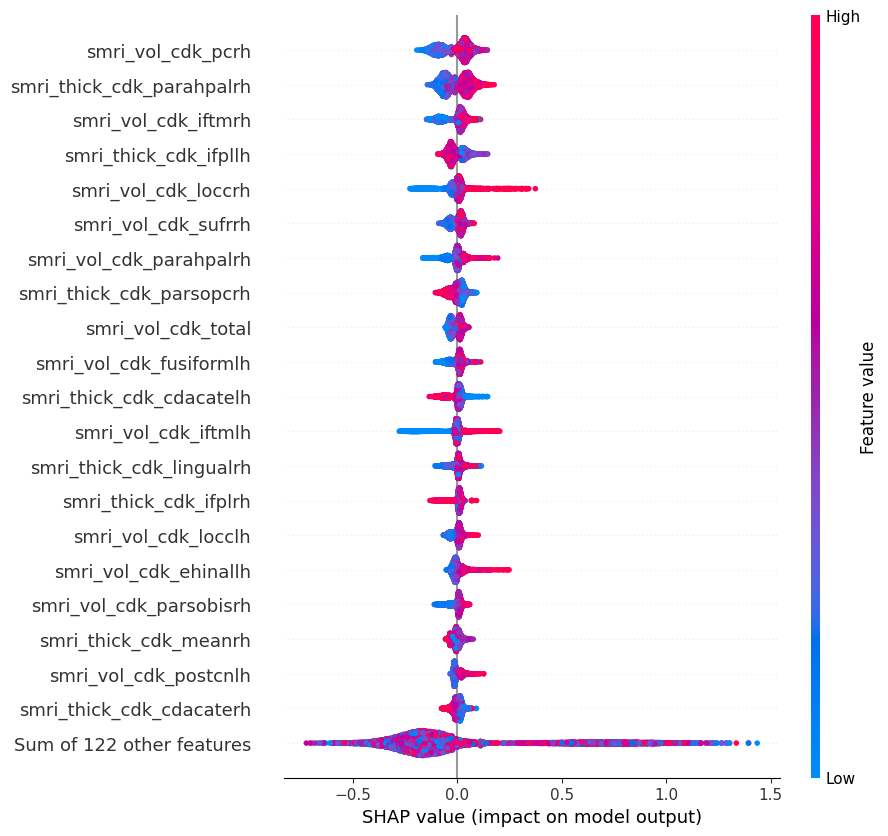

In [12]:
shap.plots.beeswarm(shap_values, max_display=21)

# SHAP dependence plots

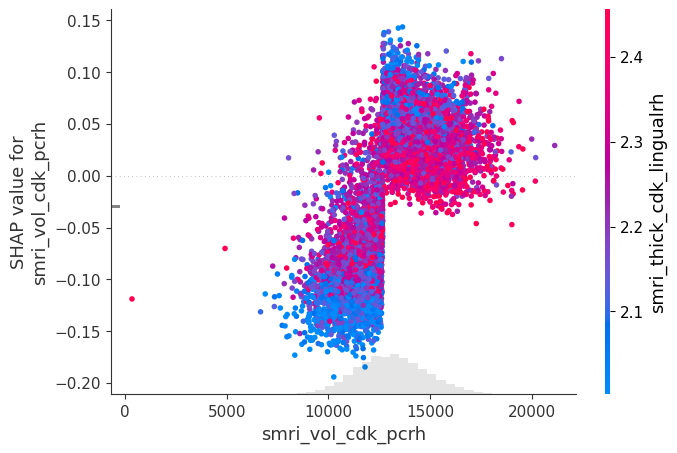

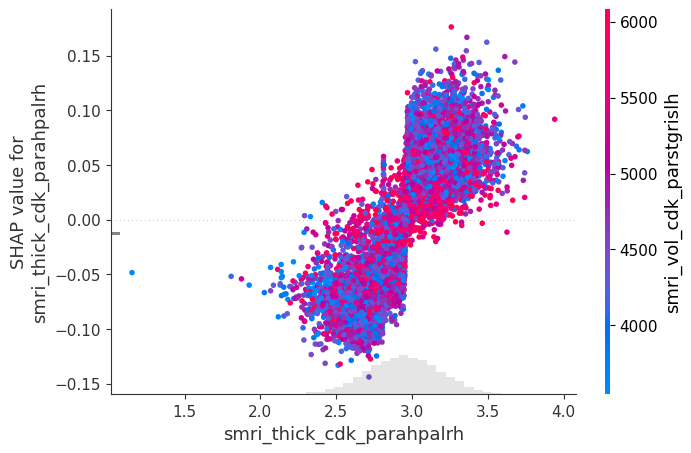

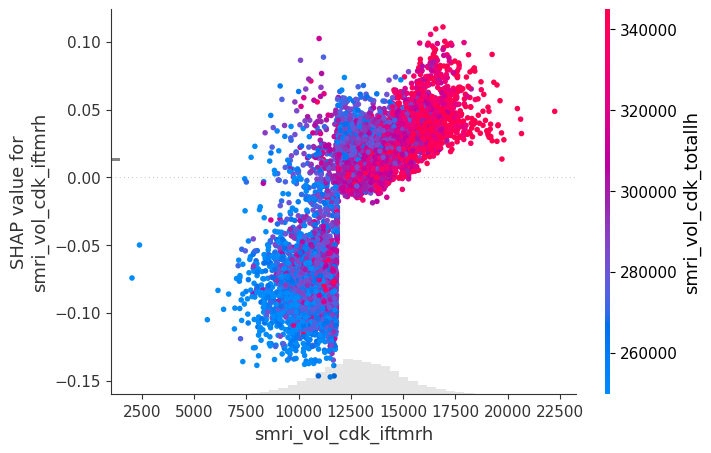

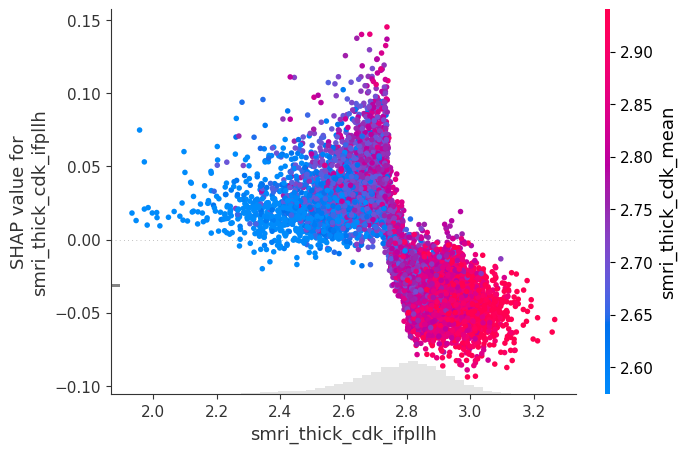

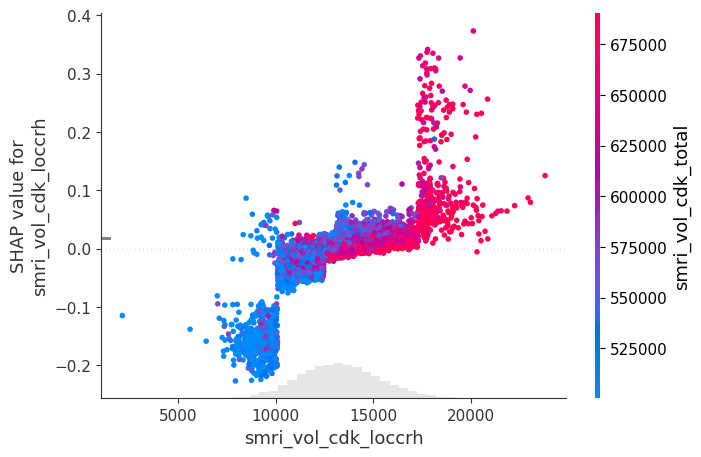

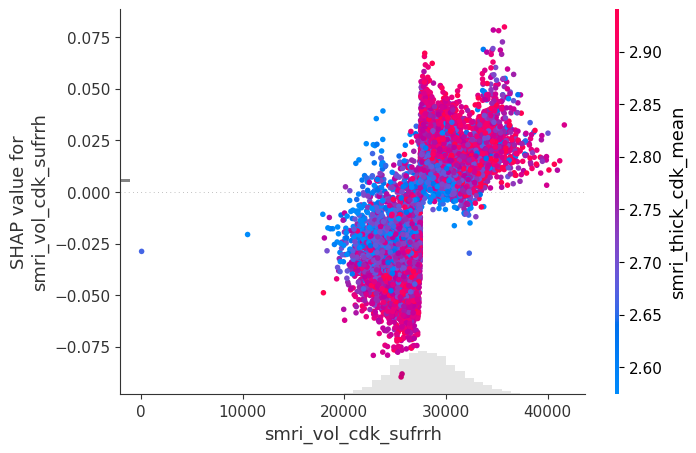

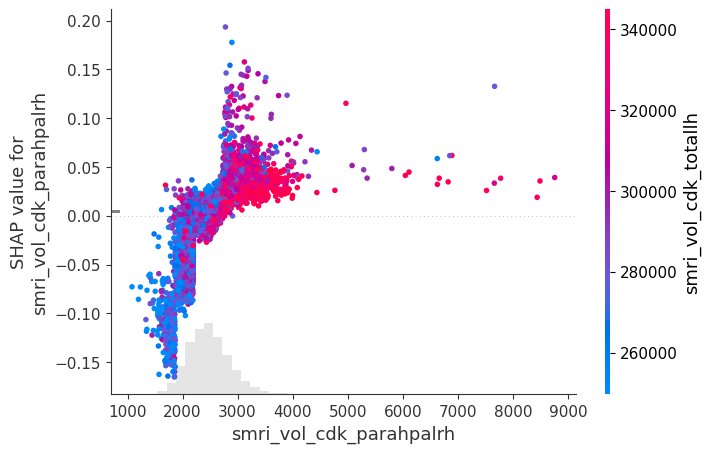

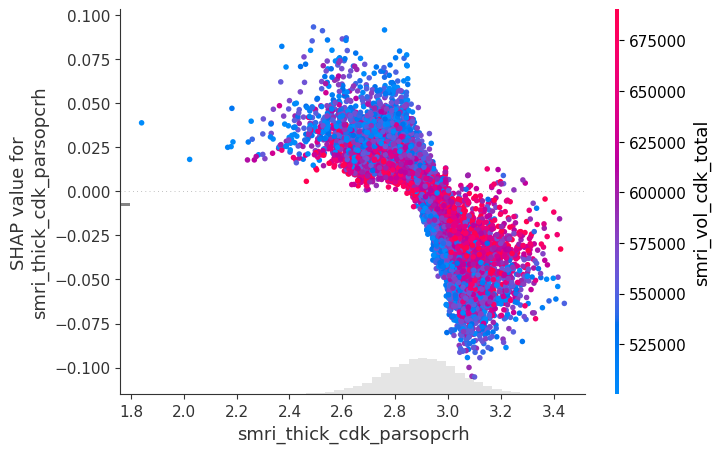

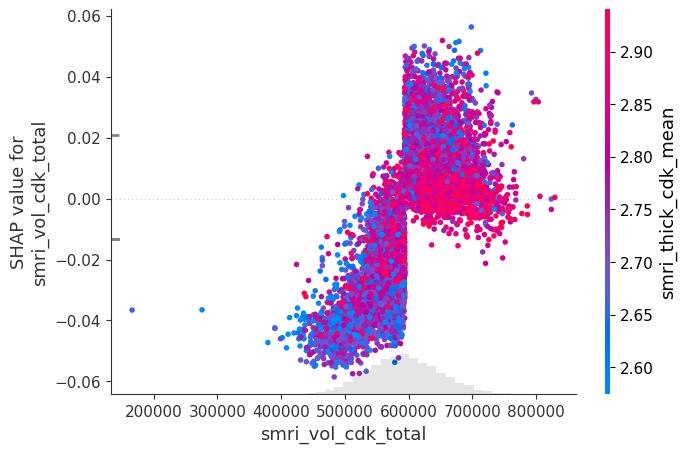

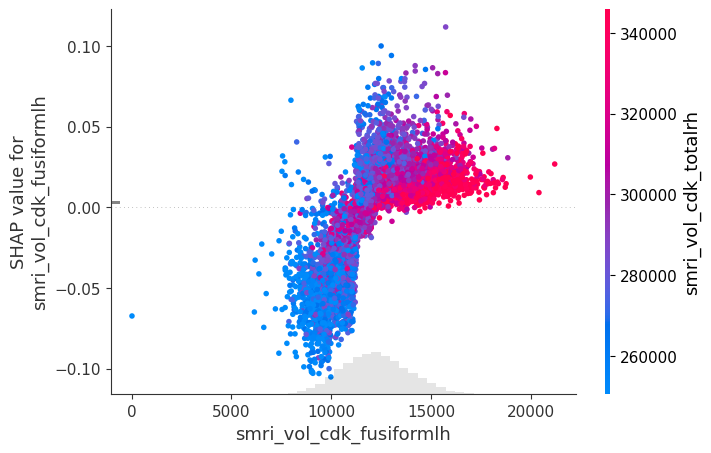

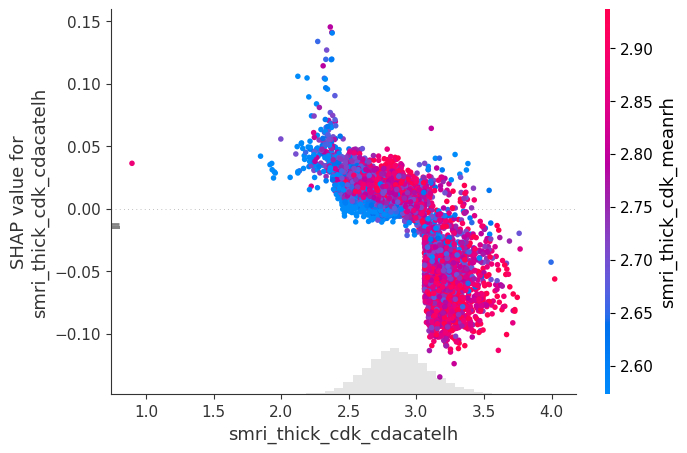

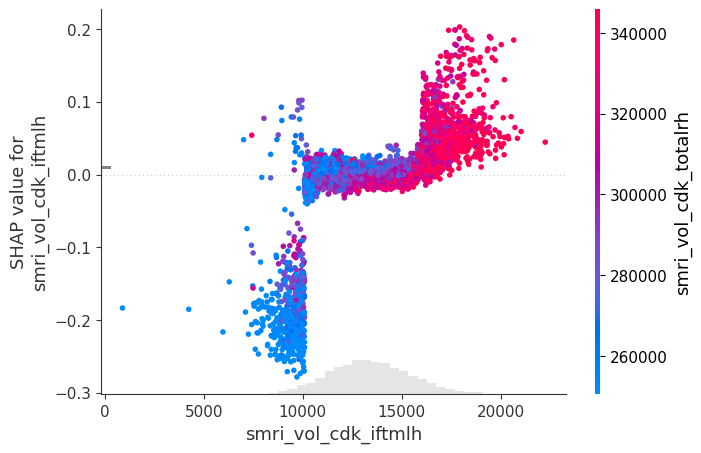

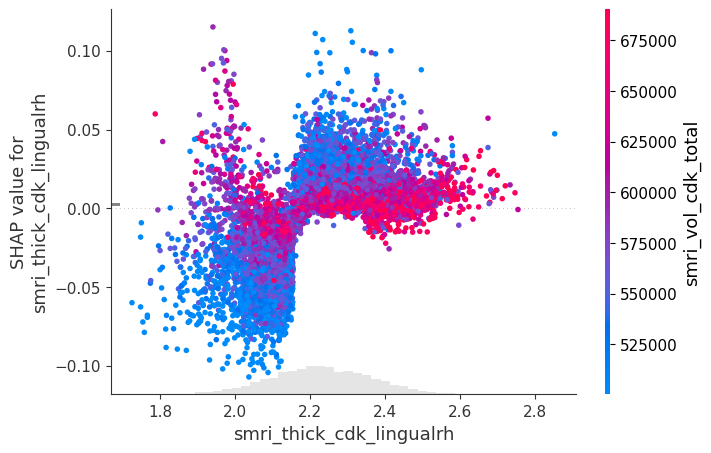

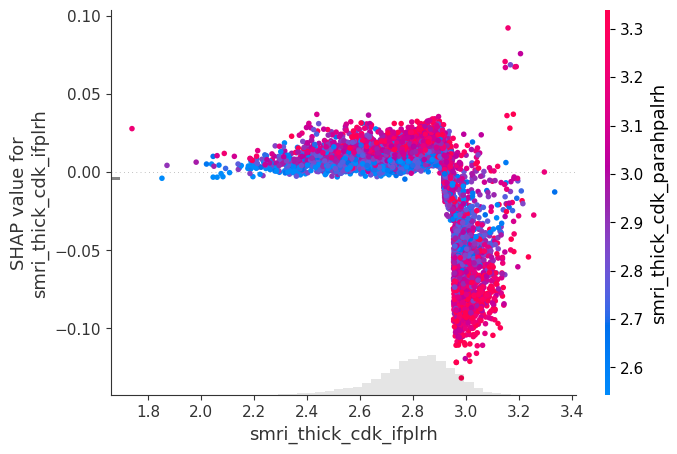

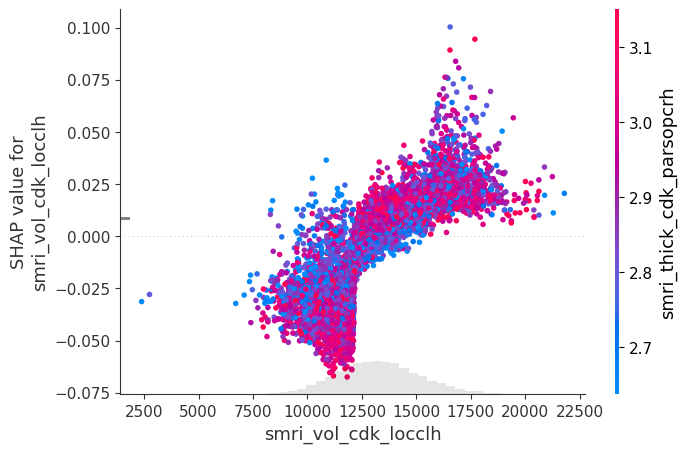

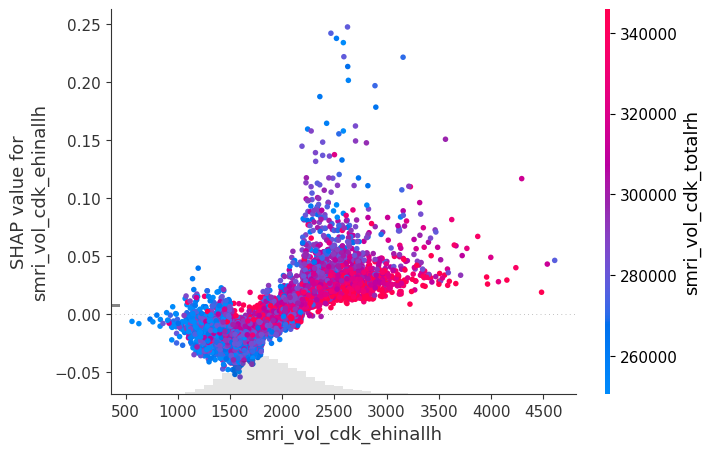

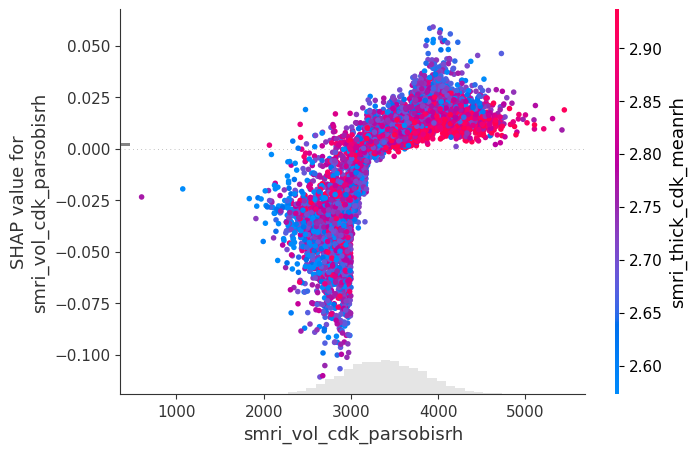

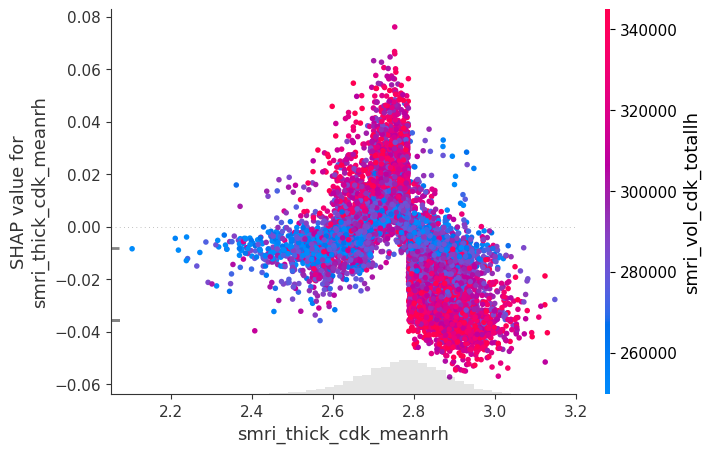

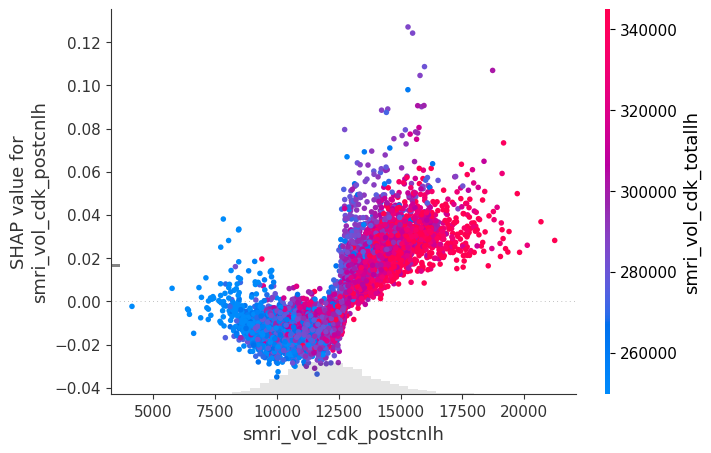

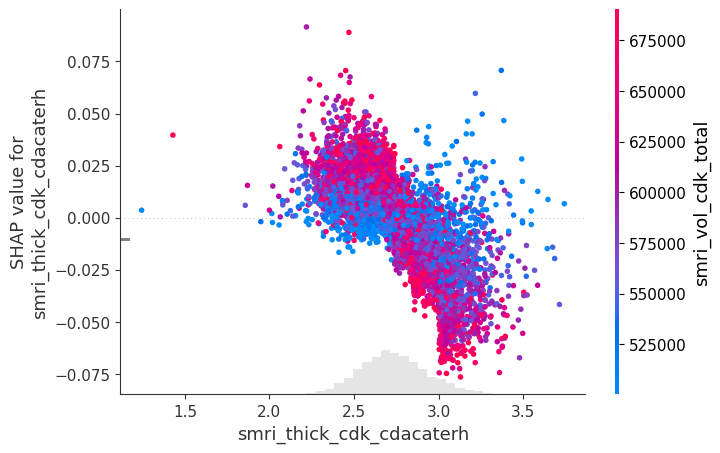

In [13]:
top_inds = np.argsort(-np.sum(np.abs(shap_values.values), 0))
for i in range(20):
    shap.plots.scatter(shap_values[:, top_inds[i]], color=shap_values)